In [ ]:
%pip install -q ipywidgets

# import

In [7]:
import tarfile
from pathlib import Path
import pandas as pd
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="torch.cuda")
import sys
from pathlib import Path

In [2]:
!git clone https://github.com/NVIDIA-AI-Blueprints/transaction-foundation-model.git

Cloning into 'transaction-foundation-model'...
remote: Enumerating objects: 205, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 205 (delta 34), reused 35 (delta 32), pack-reused 152 (from 1)
Receiving objects: 100% (205/205), 708.74 KiB | 2.31 MiB/s, done.
Resolving deltas: 100% (82/82), done.


In [3]:
DATA_DIR = Path("data/TabFormer/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)

TEMPORAL_SPLIT_DIR = Path("data/TabFormer/temporal_split")
TEMPORAL_SPLIT_DIR.mkdir(parents=True, exist_ok=True)

TGZ_PATH = DATA_DIR.parent / "transactions.tgz"

In [4]:
%cd /content/transaction-foundation-model

/content/transaction-foundation-model


In [5]:
from src.tokenizer import FinancialTokenizerPipeline, FinancialTabularTokenizer

In [9]:
%cd ..

/content


In [10]:
PROJECT_ROOT = Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

TEMPORAL_SPLIT_DIR = PROJECT_ROOT / "data" / "TabFormer" / "temporal_split"
TRAIN_DATA = TEMPORAL_SPLIT_DIR / "train.parquet"
VAL_DATA   = TEMPORAL_SPLIT_DIR / "val.parquet"
TEST_DATA  = TEMPORAL_SPLIT_DIR / "test.parquet"

for p in [TRAIN_DATA, VAL_DATA, TEST_DATA]:
    assert p.exists(), f"Missing temporal split: {p}  (run notebook 01 first)"

CORPUS_DIR = PROJECT_ROOT / "data" / "decoder_corpus"
CORPUS_PATH      = CORPUS_DIR / "train_corpus.txt"
VAL_CORPUS_PATH  = CORPUS_DIR / "val_corpus.txt"
TEST_CORPUS_PATH = CORPUS_DIR / "test_corpus.txt"

# from src.tokenizer import FinancialTokenizerPipeline, FinancialTabularTokenizer

print(f"Project Root      : {PROJECT_ROOT}")
print(f"Temporal Splits   : {TEMPORAL_SPLIT_DIR}")
print(f"  Train           : {TRAIN_DATA}")
print(f"  Val             : {VAL_DATA}")
print(f"  Test            : {TEST_DATA}")
print(f"Output Corpora    : {CORPUS_DIR}")
print(f"  Train Corpus    : {CORPUS_PATH}")
print(f"  Val Corpus      : {VAL_CORPUS_PATH}")
print(f"  Test Corpus     : {TEST_CORPUS_PATH}")

Project Root      : /content
Temporal Splits   : /content/data/TabFormer/temporal_split
  Train           : /content/data/TabFormer/temporal_split/train.parquet
  Val             : /content/data/TabFormer/temporal_split/val.parquet
  Test            : /content/data/TabFormer/temporal_split/test.parquet
Output Corpora    : /content/data/decoder_corpus
  Train Corpus    : /content/data/decoder_corpus/train_corpus.txt
  Val Corpus      : /content/data/decoder_corpus/val_corpus.txt
  Test Corpus     : /content/data/decoder_corpus/test_corpus.txt


In [11]:
import torch
import cudf
from transformers import AutoTokenizer

pipeline = FinancialTokenizerPipeline(merchant_hash_size=2000)
fin_tokenizer = FinancialTabularTokenizer(merchant_hash_size=2000)
gpt2_tokenizer = AutoTokenizer.from_pretrained("gpt2")

print(f"Financial Vocab Size: {fin_tokenizer.get_vocab_size()}")
print(f"  Pipeline steps    : {len(pipeline.tokenizer_order)}")
print(f"  Step names        : {pipeline.tokenizer_order}")
print(f"GPT-2 Vocab Size    : {gpt2_tokenizer.vocab_size}")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Financial Vocab Size: 6251
  Pipeline steps    : 12
  Step names        : ['amt_val', 'merch_hash', 'mcc_int', 'mcc_str', 'hour', 'dow', 'month', 'card', 'chip_upper', 'zip3', 'state_clean', 'cust']
GPT-2 Vocab Size    : 50257


# 1.2 Sample Transaction

In [ ]:
# Build a single-row cuDF DataFrame matching the TabFormer schema
sample_df = cudf.DataFrame({
    "Amount":         ["$42.75"],
    "Merchant Name":  ["3527213246127876953"],
    "MCC":            [5411],
    "Year":           [2025],
    "Month":          [1],
    "Day":            [15],
    "Time":           ["09:32"],
    "Card":           [0],
    "Use Chip":       ["Chip Transaction"],
    "Zip":            ["95113.0"],
    "Merchant State": ["CA"],
    "User":           [1001],
})

# Run the full pipeline: preprocess → fit → transform
processed = FinancialTokenizerPipeline.preprocess(sample_df)
pipeline.fit(processed)
token_df = pipeline.transform(processed)

# Show per-field tokens
print("Pipeline token output (one column per field):")
print(token_df.to_pandas().iloc[0].to_dict())

# Assemble into the text format used by the decoder training corpus
token_cols = list(token_df.columns)
txn_str = " ".join(token_df[c].to_pandas().iloc[0] for c in token_cols)
financial_text = f"<bos> {txn_str} <eos>"
print(f"\nFull token sequence:\n{financial_text}")

In [14]:
# Build a single-row cuDF DataFrame matching the TabFormer schema
sample_df = cudf.DataFrame({
    "Amount":         ["$42.75"],
    "Merchant Name":  ["3527213246127876953"],
    "MCC":            [5411],
    "Year":           [2025],
    "Month":          [1],
    "Day":            [15],
    "Time":           ["09:32"],
    "Card":           [0],
    "Use Chip":       ["Chip Transaction"],
    "Zip":            ["95113.0"],
    "Merchant State": ["CA"],
    "User":           [1001],
})

import time

# Preprocess
start = time.perf_counter()
processed = FinancialTokenizerPipeline.preprocess(sample_df)
print(f"Preprocess: {time.perf_counter() - start:.4f} seconds")

# Fit
start = time.perf_counter()
pipeline.fit(processed)
print(f"Fit:        {time.perf_counter() - start:.4f} seconds")

# Transform
start = time.perf_counter()
token_df = pipeline.transform(processed)
print(f"Transform:  {time.perf_counter() - start:.4f} seconds")



Preprocess: 0.0602 seconds
Fit:        0.0182 seconds
Transform:  0.1210 seconds


In [20]:
display(sample_df)
display(token_df)

,amount,merchant_name,mcc,year,month,day,time,card,use_chip,zip,...,merch_hash,mcc_int,mcc_str,hour,dow,chip_upper,zip3,state_clean,cust,time_full
0,$42.75,3527213246127876953,5411,2025,1,15,09:32,0,Chip Transaction,95113.0,...,1297092898,5411,5411,9,2,CHIP TRANSACTION,951,CA,1001,2025-01-15 09:32:00


,amt_val,merch_hash,mcc_int,mcc_str,hour,dow,month,card,chip_upper,zip3,state_clean,cust
0,AMT_1,MERCH_898,CAT_RETAIL,MCC_5411,HOUR_09,DOW_2,MONTH_01,CARD_0,CHIP_CHIP,ZIP3_951,STATE_CA,CUST_1001


In [16]:
# Assemble into the text format used by the decoder training corpus
token_cols = list(token_df.columns)
txn_str = " ".join(token_df[c].to_pandas().iloc[0] for c in token_cols)
financial_text = f"<bos> {txn_str} <eos>"
print(f"\nFull token sequence:\n{financial_text}")


Full token sequence:
<bos> AMT_1 MERCH_898 CAT_RETAIL MCC_5411 HOUR_09 DOW_2 MONTH_01 CARD_0 CHIP_CHIP ZIP3_951 STATE_CA CUST_1001 <eos>


# 1.3 Tokenizer Comparison

In [17]:
fin_tokens = financial_text.split()

raw_tabular_text = (
    "$42.75, 3527213246127876953, 5411, "
    "2025-01-15, 09:32, 0, Chip Transaction, "
    "95113, CA, 1001"
)

print("=" * 70)
print("TOKENIZER COMPARISON: Same Transaction, Two Approaches")
print("=" * 70)

print(f"\n--- Financial Tokenizer (domain-specific pipeline) ---")
print(f"Input : raw tabular fields → binning + hashing + encoding")
print(f"Count : {len(fin_tokens)} tokens")
print(f"Tokens: {fin_tokens}\n")

gpt2_tokens = gpt2_tokenizer.tokenize(raw_tabular_text)
print(f"--- GPT-2 BPE Tokenizer (on raw tabular text) ---")
print(f"Input : {raw_tabular_text}")
print(f"Count : {len(gpt2_tokens)} tokens")
print(f"Tokens: {gpt2_tokens}")

TOKENIZER COMPARISON: Same Transaction, Two Approaches

--- Financial Tokenizer (domain-specific pipeline) ---
Input : raw tabular fields → binning + hashing + encoding
Count : 14 tokens
Tokens: ['<bos>', 'AMT_1', 'MERCH_898', 'CAT_RETAIL', 'MCC_5411', 'HOUR_09', 'DOW_2', 'MONTH_01', 'CARD_0', 'CHIP_CHIP', 'ZIP3_951', 'STATE_CA', 'CUST_1001', '<eos>']

--- GPT-2 BPE Tokenizer (on raw tabular text) ---
Input : $42.75, 3527213246127876953, 5411, 2025-01-15, 09:32, 0, Chip Transaction, 95113, CA, 1001
Count : 39 tokens
Tokens: ['$', '42', '.', '75', ',', 'Ġ35', '27', '213', '246', '12', '787', '69', '53', ',', 'Ġ54', '11', ',', 'Ġ2025', '-', '01', '-', '15', ',', 'Ġ09', ':', '32', ',', 'Ġ0', ',', 'ĠChip', 'ĠTransaction', ',', 'Ġ95', '113', ',', 'ĠCA', ',', 'Ġ100', '1']


# 1.4 Quantitative Summary

In [22]:
fin_count = len(fin_tokens)
gpt2_count = len(gpt2_tokens)

CONTEXT_WINDOW = 4096
TOKENS_PER_TXN_SEP = 1

fin_per_txn = fin_count - 2  # subtract <bos>/<eos> (per-sequence overhead, not per-txn)
fin_txns_per_seq = CONTEXT_WINDOW // (fin_per_txn + TOKENS_PER_TXN_SEP)
gpt2_txns_per_seq = CONTEXT_WINDOW // (gpt2_count + TOKENS_PER_TXN_SEP)

print("=" * 70)
print("TOKENIZER COMPARISON SUMMARY")
print("=" * 70)
print(f"{'Tokenizer':<20} {'Tokens/Txn':>12} {'Compression':>14} {'Txns in 4096':>15}")
print("-" * 70)
print(f"{'Financial':<20} {fin_per_txn:>12} {'1x (baseline)':>14} {f'~{fin_txns_per_seq}':>15}")
print(f"{'GPT-2 (BPE)':<20} {gpt2_count:>12} {f'{gpt2_count/fin_per_txn:.1f}x more':>14} {f'~{gpt2_txns_per_seq}':>15}")
print("-" * 70)
print(f"\nWith a 4096-token context window:")
print(f"  Financial tokenizer: ~{fin_txns_per_seq} transactions of temporal context")
print(f"  GPT-2 BPE tokenizer: ~{gpt2_txns_per_seq} transactions")

TOKENIZER COMPARISON SUMMARY
Tokenizer              Tokens/Txn    Compression    Txns in 4096
----------------------------------------------------------------------
Financial                      12  1x (baseline)            ~315
GPT-2 (BPE)                    39      3.2x more            ~102
----------------------------------------------------------------------

With a 4096-token context window:
  Financial tokenizer: ~315 transactions of temporal context
  GPT-2 BPE tokenizer: ~102 transactions


# 1.5 Analysis: Why This Matters

In [23]:
def quick_tokenize(overrides: dict) -> str:
    """Helper: tokenize a single transaction with field overrides."""
    row = {
        "Amount": ["$42.75"], "Merchant Name": ["3527213246127876953"],
        "MCC": [5411], "Year": [2025], "Month": [1], "Day": [15],
        "Time": ["09:32"], "Card": [0], "Use Chip": ["Chip Transaction"],
        "Zip": ["95113.0"], "Merchant State": ["CA"], "User": [1001],
    }
    row.update({k: [v] for k, v in overrides.items()})
    gdf = cudf.DataFrame(row)
    gdf = FinancialTokenizerPipeline.preprocess(gdf)
    tdf = pipeline.transform(gdf)
    return " ".join(tdf[c].to_pandas().iloc[0] for c in tdf.columns)

print("Large amount ($8,500):")
tokens = quick_tokenize({"Amount": "$8500.00"})
print(f"  {tokens.split()[0]}  (AMT_6 = $5,000+)")

print("\nOnline transaction (no physical location):")
tokens = quick_tokenize({"Use Chip": "Online Transaction", "Zip": "00000", "Merchant State": ""})
print(f"  Tokens: {tokens}")

print("\nSmall amount ($0.50):")
tokens = quick_tokenize({"Amount": "$0.50"})
print(f"  {tokens.split()[0]}  (AMT_0 = $0-10)")

print("\nThe tokenizer maps all amounts to 7 log-scale bins, preserving magnitude")
print("while avoiding the sparsity of exact dollar amounts.")

Large amount ($8,500):
  AMT_6  (AMT_6 = $5,000+)

Online transaction (no physical location):
  Tokens: AMT_1 MERCH_898 CAT_RETAIL MCC_5411 HOUR_09 DOW_2 MONTH_01 CARD_0 CHIP_ONLINE ZIP3_000 STATE_XX CUST_1001

Small amount ($0.50):
  AMT_0  (AMT_0 = $0-10)

The tokenizer maps all amounts to 7 log-scale bins, preserving magnitude
while avoiding the sparsity of exact dollar amounts.


# 2. Generate Tokenized Corpora (Train / Val / Test)

In [24]:
import time
import cudf

MERCHANT_HASH_SIZE = 2000
CHUNK_SIZE = 315  # ~4096 tokens with 12 tok/txn + separators

CORPUS_DIR.mkdir(parents=True, exist_ok=True)

In [25]:
splits = [
    ("train", TRAIN_DATA, CORPUS_PATH),
    ("val",   VAL_DATA,   VAL_CORPUS_PATH),
    ("test",  TEST_DATA,  TEST_CORPUS_PATH),
]


In [45]:


for split_name, parquet_path, corpus_path in splits:

    if corpus_path.exists():
        n_lines = sum(1 for _ in open(corpus_path))
        print(f"[{split_name}] Corpus already exists: {n_lines:,} sequences")
        continue
    else:
        print(f"[{split_name}] Generating corpus...")


    t0 = time.time()
    gdf = cudf.read_parquet(str(parquet_path))
    print(f"  Loaded {len(gdf):,} rows in {time.time()-t0:.1f}s")

    pip = FinancialTokenizerPipeline(merchant_hash_size=MERCHANT_HASH_SIZE)
    gdf_proc = pip.preprocess(gdf)
    pip.fit(gdf_proc)
    token_df = pip.transform(gdf_proc)

    # Identify grouping columns for chunking by (user, card)
    group_cols = []
    for col_name in ["user", "User", "cust"]:
        if col_name in gdf_proc.columns:
            group_cols.append(col_name)
            break
    for col_name in ["card", "Card", "card_id"]:
        if col_name in gdf_proc.columns:
            group_cols.append(col_name)
            break

    if not group_cols:
        group_cols = [gdf_proc.columns[0]]

    print(f"  Grouping by: {group_cols}")
    print(f"  Chunk size: {CHUNK_SIZE} transactions (~{CHUNK_SIZE * 13} tokens)")

    corpus_lines = pip.to_corpus_lines(
        token_df, gdf_proc, group_cols, chunk_size=CHUNK_SIZE
    )

    with open(corpus_path, "w") as f:
        for line in corpus_lines:
            f.write(line + "\n")

    elapsed = time.time() - t0
    print(f"  Generated {len(corpus_lines):,} sequences in {elapsed:.1f}s")
    print(f"  Saved to: {corpus_path}")

    sample = corpus_lines[0]
    n_tokens = len(sample.split())
    n_seps = sample.count("<sep>")
    print(f"  Sample: {n_tokens} tokens, {n_seps+1} transactions")
    print(f"  Preview: {sample[:200]}...")

    # break

[train] Generating corpus...
  Loaded 79,997 rows in 0.0s
  Grouping by: ['user', 'card']
  Chunk size: 315 transactions (~4095 tokens)
  Generated 265 sequences in 0.6s
  Saved to: /content/data/decoder_corpus/train_corpus.txt
  Sample: 4096 tokens, 315 transactions
  Preview: <bos> AMT_3 MERCH_898 CAT_RETAIL MCC_5300 HOUR_06 DOW_6 MONTH_09 CARD_0 CHIP_SWIPE ZIP3_917 STATE_CA CUST_0 <sep> AMT_1 MERCH_1100 CAT_RETAIL MCC_5411 HOUR_06 DOW_6 MONTH_09 CARD_0 CHIP_SWIPE ZIP3_917...
[val] Generating corpus...
  Loaded 9,993 rows in 0.0s
  Grouping by: ['user', 'card']
  Chunk size: 315 transactions (~4095 tokens)
  Generated 40 sequences in 0.4s
  Saved to: /content/data/decoder_corpus/val_corpus.txt
  Sample: 4096 tokens, 315 transactions
  Preview: <bos> AMT_2 MERCH_801 CAT_RETAIL MCC_5311 HOUR_13 DOW_3 MONTH_12 CARD_0 CHIP_CHIP ZIP3_919 STATE_CA CUST_0 <sep> AMT_3 MERCH_429 CAT_RETAIL MCC_5411 HOUR_06 DOW_5 MONTH_12 CARD_0 CHIP_CHIP ZIP3_917 ST...
[test] Generating corpus...
  Loaded 10,

In [38]:
type(gdf_proc)

cudf.core.dataframe.DataFrame

In [37]:
token_df.head(5)

,amt_val,merch_hash,mcc_int,mcc_str,hour,dow,month,card,chip_upper,zip3,state_clean,cust
0,AMT_3,MERCH_898,CAT_RETAIL,MCC_5300,HOUR_06,DOW_6,MONTH_09,CARD_0,CHIP_SWIPE,ZIP3_917,STATE_CA,CUST_0
1,AMT_1,MERCH_1100,CAT_RETAIL,MCC_5411,HOUR_06,DOW_6,MONTH_09,CARD_0,CHIP_SWIPE,ZIP3_917,STATE_CA,CUST_0
2,AMT_3,MERCH_1100,CAT_RETAIL,MCC_5411,HOUR_06,DOW_0,MONTH_09,CARD_0,CHIP_SWIPE,ZIP3_917,STATE_CA,CUST_0
3,AMT_3,MERCH_426,CAT_CLOTHING,MCC_5651,HOUR_17,DOW_0,MONTH_09,CARD_0,CHIP_SWIPE,ZIP3_917,STATE_CA,CUST_0
4,AMT_3,MERCH_159,CAT_MISC_STORES,MCC_5912,HOUR_06,DOW_1,MONTH_09,CARD_0,CHIP_SWIPE,ZIP3_917,STATE_CA,CUST_0


In [33]:
gdf_proc.columns

Index(['user', 'card', 'year', 'month', 'day', 'time', 'amount', 'use_chip',
       'merchant_name', 'merchant_city', 'merchant_state', 'zip', 'mcc',
       'errors?', 'is_fraud?', 'amt_val', 'merch_hash', 'mcc_int', 'mcc_str',
       'hour', 'dow', 'chip_upper', 'zip3', 'state_clean', 'cust', 'time_full',
       'time_delta_s'],
      dtype='object')

In [35]:
gdf_proc.columns[0]

'user'

In [44]:
# # Identify grouping columns for chunking by (user, card)
# group_cols = []
# for col_name in ["user", "User", "cust"]:
#     if col_name in gdf_proc.columns:
#         group_cols.append(col_name)
#         break
# for col_name in ["card", "Card", "card_id"]:
#     if col_name in gdf_proc.columns:
#         group_cols.append(col_name)
#         break
# group_cols

# if not group_cols:
#     group_cols = [gdf_proc.columns[0]]

# print(f"  Grouping by: {group_cols}")
# print(f"  Chunk size: {CHUNK_SIZE} transactions (~{CHUNK_SIZE * 13} tokens)")

# # both token_df, gdf_proc are dataframe
# corpus_lines = pip.to_corpus_lines(
#     token_df, gdf_proc, group_cols, chunk_size=CHUNK_SIZE
# )

# # with open(corpus_path, "w") as f:
# #     for line in corpus_lines:
# #         f.write(line + "\n")

# elapsed = time.time() - t0
# print(f"  Generated {len(corpus_lines):,} sequences in {elapsed:.1f}s")
# print(f"  Saved to: {corpus_path}")

# sample = corpus_lines[0]
# n_tokens = len(sample.split())
# n_seps = sample.count("<sep>")
# print(f"  Sample: {n_tokens} tokens, {n_seps+1} transactions")
# print(f"  Preview: {sample[:200]}...")

  Grouping by: ['user', 'card']
  Chunk size: 315 transactions (~4095 tokens)
  Generated 265 sequences in 519.4s
  Saved to: /content/data/decoder_corpus/train_corpus.txt
  Sample: 4096 tokens, 315 transactions
  Preview: <bos> AMT_3 MERCH_898 CAT_RETAIL MCC_5300 HOUR_06 DOW_6 MONTH_09 CARD_0 CHIP_SWIPE ZIP3_917 STATE_CA CUST_0 <sep> AMT_1 MERCH_1100 CAT_RETAIL MCC_5411 HOUR_06 DOW_6 MONTH_09 CARD_0 CHIP_SWIPE ZIP3_917...


In [46]:
import os

print("Corpus Summary:")
print("=" * 60)
for name, path in [("Train", CORPUS_PATH), ("Val", VAL_CORPUS_PATH), ("Test", TEST_CORPUS_PATH)]:
    n_lines = sum(1 for _ in open(path))
    size_mb = os.path.getsize(path) / (1024 * 1024)
    print(f"  {name:6s}: {n_lines:>8,} sequences  ({size_mb:>7.1f} MB)  {path.name}")

print(f"\nFirst 3 lines of {CORPUS_PATH.name}:")
with open(CORPUS_PATH, 'r') as f:
    for _ in range(3):
        line = f.readline().strip()
        print(f"  {line[:120]}...")

Corpus Summary:
  Train :      265 sequences  (    8.5 MB)  train_corpus.txt
  Val   :       40 sequences  (    1.1 MB)  val_corpus.txt
  Test  :       40 sequences  (    1.1 MB)  test_corpus.txt

First 3 lines of train_corpus.txt:
  <bos> AMT_3 MERCH_898 CAT_RETAIL MCC_5300 HOUR_06 DOW_6 MONTH_09 CARD_0 CHIP_SWIPE ZIP3_917 STATE_CA CUST_0 <sep> AMT_1 ...
  <bos> AMT_1 MERCH_1100 CAT_RETAIL MCC_5411 HOUR_06 DOW_3 MONTH_12 CARD_0 CHIP_SWIPE ZIP3_917 STATE_CA CUST_0 <sep> AMT_2...
  <bos> AMT_1 MERCH_1259 CAT_MISC_STORES MCC_5912 HOUR_19 DOW_4 MONTH_08 CARD_0 CHIP_SWIPE ZIP3_917 STATE_CA CUST_0 <sep> ...


In [47]:
print(1)

1


In [48]:
import transformers


# NB4

In [59]:
%cd /content/transaction-foundation-model
!apt-get update -qq
!apt-get install -y git-lfs
!git lfs install
!git lfs pull
%cd ..

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git-lfs is already the newest version (3.4.1-1ubuntu0.4).
0 upgraded, 0 newly installed, 0 to remove and 54 not upgraded.


In [62]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="torch.cuda")
warnings.filterwarnings("ignore", message="The '.*' attribute with value.*was provided")

import sys
import json
from pathlib import Path

import torch
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


DATA_DIR = PROJECT_ROOT / "data"
PREPROCESSED_DIR = DATA_DIR / "TabFormer/temporal_split"
MODEL_DIR = PROJECT_ROOT / "transaction-foundation-model/models/decoder-foundation-model"
EMBED_DIR = DATA_DIR / "embeddings"
EMBED_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Project root:  {PROJECT_ROOT}")
print(f"Model:         {MODEL_DIR}")
print(f"Data:          {PREPROCESSED_DIR}")
print(f"Output:        {EMBED_DIR}")
print(f"Device:        {DEVICE}")

Project root:  /content
Model:         /content/transaction-foundation-model/models/decoder-foundation-model
Data:          /content/data/TabFormer/temporal_split
Output:        /content/data/embeddings
Device:        cuda


# 1. Extract Embeddings (cuDF-Accelerated)

In [67]:
import time
import cudf

# ==============================================================================
# Configuration
# ==============================================================================
BATCH_SIZE = 1024
MAX_LENGTH = 128
MERCHANT_HASH_SIZE = 2000  # Aligned with corpus generation (notebook 02)
BALANCED_TRAIN_SIZE = 1_000_000


In [65]:
%pwd

'/content'

In [68]:
# ==============================================================================
from src.tokenizer import FinancialTokenizerPipeline, FinancialTabularTokenizer
from src.decoder_inference import HuggingFaceDecoderInference

pipeline = FinancialTokenizerPipeline(merchant_hash_size=MERCHANT_HASH_SIZE)

tokenizer = FinancialTabularTokenizer(
    merchant_hash_size=MERCHANT_HASH_SIZE,
    category_hierarchy=True,
    temporal_encoding=True,
)
print(f"Tokenizer: vocab_size={tokenizer.vocab_size}")

Tokenizer: vocab_size=6251


In [70]:
assert MODEL_DIR.exists() and (MODEL_DIR / "config.json").exists(), \
    (f"Decoder checkpoint not found at {MODEL_DIR}. "
     "Run 'git lfs pull' inside the container to download the pre-trained model. "
     "If the repo is bind-mounted, you may also need: "
     "git config --global --add safe.directory /workspace")
print(f"Model path: {MODEL_DIR}")


Model path: /content/transaction-foundation-model/models/decoder-foundation-model


In [71]:
inference = HuggingFaceDecoderInference(
    model_path=MODEL_DIR,
    tokenizer=tokenizer,
    pooling="last_token",
)
print(f"Model loaded on {inference.device} (embed_dim={inference.embedding_dim})")


Loading weights:   0%|          | 0/75 [00:00<?, ?it/s]

Model loaded on cuda (embed_dim=512)


In [72]:
all_embeddings = []
all_labels = []
split_sizes = {}

split_to_parquet = {"train": "train.parquet", "val": "val_eval.parquet", "test": "test_eval.parquet"}

In [86]:
for split in ("train", "val", "test"):
    embed_path = EMBED_DIR / f"{split}_embeddings.npy"
    label_path = EMBED_DIR / f"{split}_labels.npy"
    row_id_path = EMBED_DIR / f"{split}_row_ids.npy"

    if embed_path.exists() and label_path.exists():
        emb = np.load(embed_path)
        lbl = np.load(label_path)
        if row_id_path.exists():
            row_ids = np.load(row_id_path)
            assert len(row_ids) == len(emb), (
                f"Row-ID mismatch for {split}: {len(row_ids)} ids vs {len(emb)} embeddings"
            )
        else:
            row_ids = np.arange(len(emb), dtype=np.int64)
            if split == "train":
                print(
                    f"[{split}] WARNING: {row_id_path.name} missing; "
                    "saved labels/raw-feature joins assume positional alignment. "
                    "Re-run extraction to regenerate explicit row IDs."
                )
            else:
                print(
                    f"[{split}] WARNING: {row_id_path.name} missing; "
                    "visualization metadata will fall back to positional order. "
                    "Re-run extraction to regenerate explicit row IDs."
                )
        print(f"[{split}] Already extracted: {emb.shape}, "
              f"{lbl.sum():,} fraud / {len(lbl):,}")
        all_embeddings.append(emb)
        all_labels.append(lbl)
        split_sizes[split] = len(emb)
        continue

    parquet_path = PREPROCESSED_DIR / split_to_parquet[split]
    print(f"\n{'='*60}")
    print(f"Extracting {split} embeddings")
    print(f"{'='*60}")

    # GPU-accelerated tokenization
    t0 = time.time()
    gdf = cudf.read_parquet(str(parquet_path))

    # # Extract labels BEFORE preprocessing (which renames columns)
    labels = None
    for col in ["Is Fraud?", "is_fraud", "Is_Fraud", "label", "fraud"]:
        if col in gdf.columns:
            lbl = gdf[col].to_pandas()
            if lbl.dtype == object:
                labels = ((lbl == "Yes") | (lbl == "1")).astype(int).values
            else:
                labels = lbl.astype(int).values
            print(f"  Labels from '{col}': {labels.sum():,} fraud / {len(labels):,}")
            break

    print(labels)

    # Balanced sampling for training set (deterministic seed, matches NB05)
    if split == "train" and labels is not None:
        fraud_idx = np.where(labels == 1)[0].tolist()
        normal_idx = np.where(labels == 0)[0].tolist()
        np.random.seed(42)
        n_fraud = min(len(fraud_idx), int(BALANCED_TRAIN_SIZE * 0.1))
        n_normal = min(len(normal_idx), BALANCED_TRAIN_SIZE - n_fraud)

        sampled = np.concatenate([
            np.random.choice(fraud_idx, n_fraud, replace=False),
            np.random.choice(normal_idx, n_normal, replace=False),
        ])
        np.random.shuffle(sampled)
        gdf = gdf.iloc[sampled].reset_index(drop=True)
        labels = labels[sampled]
        print(f"  Balanced sample: {len(gdf):,} rows, "
              f"{labels.sum():,} fraud ({labels.mean():.1%})")

    # Preserve explicit row IDs so labels and raw metadata can be restored
    # after preprocess() re-orders transactions by user/card/time.
    gdf["__row_id__"] = np.arange(len(gdf), dtype=np.int64)
    print(gdf.shape)

    pip = FinancialTokenizerPipeline(merchant_hash_size=MERCHANT_HASH_SIZE)
    # display(gdf.head(3))
    gdf = pip.preprocess(gdf) # the preprocess will group/order by users
    # display(gdf.head(3))
    row_ids = gdf["__row_id__"].to_pandas().to_numpy(dtype=np.int64)
    print(row_ids)

    # labels is the target, because rows are reordered, labels/targets also need to get reshuffled
    if labels is not None:
        labels = labels[row_ids]

    pip.fit(gdf)
    token_df = pip.transform(gdf)
    padded_ids = pip.encode(token_df, max_length=MAX_LENGTH)
    print(padded_ids.shape) # (79997, 128)

    tok_time = time.time() - t0
    print(f"  Tokenized {len(padded_ids):,} rows in {tok_time:.1f}s")

    # GPU inference with last-token pooling
    print(f"  Extracting embeddings (batch_size={BATCH_SIZE})...")
    t0 = time.time()
    emb = inference.extract_embeddings_batched(
        padded_ids, batch_size=BATCH_SIZE, show_progress=True
    )
    inf_time = time.time() - t0
    print(f"  Extracted {emb.shape} in {inf_time:.1f}s ({len(emb)/inf_time:,.0f} samples/sec)")

    np.save(embed_path, emb)
    if labels is not None:
        np.save(label_path, labels)
    np.save(row_id_path, row_ids)
    print(f"  Saved to {embed_path}")

    all_embeddings.append(emb)
    all_labels.append(labels if labels is not None else np.zeros(len(emb), dtype=np.int8))
    split_sizes[split] = len(emb)



Extracting train embeddings
  Labels from 'Is Fraud?': 83 fraud / 79,997
[0 0 0 ... 0 0 0]
  Balanced sample: 79,997 rows, 83 fraud (0.1%)
(79997, 16)
[ 2435 18101   378 ... 78773 55411 67443]
(79997, 128)
  Tokenized 79,997 rows in 0.9s
  Extracting embeddings (batch_size=1024)...


Extracting embeddings (last_token): 100%|██████████| 79/79 [04:01<00:00,  3.06s/it]


  Extracted (79997, 512) in 242.5s (330 samples/sec)
  Saved to /content/data/embeddings/train_embeddings.npy

Extracting val embeddings
  Labels from 'Is Fraud?': 17 fraud / 5,000
[0 0 0 ... 0 0 0]
(5000, 18)
[ 349 4292 1158 ... 4297 1389 2730]
(5000, 128)
  Tokenized 5,000 rows in 0.3s
  Extracting embeddings (batch_size=1024)...


Extracting embeddings (last_token): 100%|██████████| 5/5 [00:12<00:00,  2.58s/it]


  Extracted (5000, 512) in 15.8s (316 samples/sec)
  Saved to /content/data/embeddings/val_embeddings.npy

Extracting test embeddings
  Labels from 'Is Fraud?': 5 fraud / 5,000
[0 0 0 ... 0 0 0]
(5000, 18)
[ 524 1051 3625 ... 1880 1131 1353]
(5000, 128)
  Tokenized 5,000 rows in 0.3s
  Extracting embeddings (batch_size=1024)...


Extracting embeddings (last_token): 100%|██████████| 5/5 [00:13<00:00,  2.61s/it]


  Extracted (5000, 512) in 15.9s (314 samples/sec)
  Saved to /content/data/embeddings/test_embeddings.npy


In [87]:
split_sizes

{'train': 79997, 'val': 5000, 'test': 5000}

In [88]:
# ==============================================================================
# 3. Save concatenated results + metadata
# ==============================================================================
embeddings = np.concatenate(all_embeddings)
labels = np.concatenate(all_labels)
np.save(EMBED_DIR / "embeddings.npy", embeddings)
np.save(EMBED_DIR / "labels.npy", labels)

In [89]:
metadata = {
    "backend": "huggingface_decoder",
    "pooling": "last_token",
    "model_path": str(MODEL_DIR),
    "n_samples": len(embeddings),
    "embedding_dim": int(embeddings.shape[1]),
    "batch_size": BATCH_SIZE,
    "max_length": MAX_LENGTH,
    "splits": ["train", "val", "test"],
    "n_train": split_sizes.get("train", 0),
    "n_val": split_sizes.get("val", 0),
    "n_test": split_sizes.get("test", 0),
    "row_id_alignment": "explicit_split_row_ids",
}
with open(EMBED_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"\nAll embeddings saved to {EMBED_DIR}")
print(f"  Total: {len(embeddings):,} x {embeddings.shape[1]}")
for k, v in split_sizes.items():
    print(f"  {k.capitalize()}: {v:,}")


All embeddings saved to /content/data/embeddings
  Total: 89,997 x 512
  Train: 79,997
  Val: 5,000
  Test: 5,000


# 2. Load Embeddings

In [90]:
print(f"Loading embeddings from {EMBED_DIR}...")

with open(EMBED_DIR / "metadata.json") as f:
    meta = json.load(f)

print("Metadata:")
for k, v in meta.items():
    print(f"  {k}: {v}")

Loading embeddings from /content/data/embeddings...
Metadata:
  backend: huggingface_decoder
  pooling: last_token
  model_path: /content/transaction-foundation-model/models/decoder-foundation-model
  n_samples: 89997
  embedding_dim: 512
  batch_size: 1024
  max_length: 128
  splits: ['train', 'val', 'test']
  n_train: 79997
  n_val: 5000
  n_test: 5000
  row_id_alignment: explicit_split_row_ids


In [91]:
val_emb = np.load(EMBED_DIR / "val_embeddings.npy")
val_lbl = np.load(EMBED_DIR / "val_labels.npy")
test_emb = np.load(EMBED_DIR / "test_embeddings.npy")
test_lbl = np.load(EMBED_DIR / "test_labels.npy")

val_row_id_path = EMBED_DIR / "val_row_ids.npy"
test_row_id_path = EMBED_DIR / "test_row_ids.npy"

if val_row_id_path.exists():
    val_row_ids = np.load(val_row_id_path)
    assert len(val_row_ids) == len(val_emb), (
        f"Validation row-ID mismatch: {len(val_row_ids)} ids vs {len(val_emb)} embeddings"
    )
else:
    val_row_ids = np.arange(len(val_emb), dtype=np.int64)
    print(
        f"WARNING: {val_row_id_path.name} missing; "
        "validation metadata alignment falls back to positional order. "
        "Re-run extraction to regenerate explicit row IDs."
    )

if test_row_id_path.exists():
    test_row_ids = np.load(test_row_id_path)
    assert len(test_row_ids) == len(test_emb), (
        f"Test row-ID mismatch: {len(test_row_ids)} ids vs {len(test_emb)} embeddings"
    )
else:
    test_row_ids = np.arange(len(test_emb), dtype=np.int64)
    print(
        f"WARNING: {test_row_id_path.name} missing; "
        "test metadata alignment falls back to positional order. "
        "Re-run extraction to regenerate explicit row IDs."
    )


In [92]:
print(f"\nVal  embeddings: {val_emb.shape}  |  fraud: {val_lbl.sum():,} / {len(val_lbl):,} ({val_lbl.mean():.2%})")
print(f"Test embeddings: {test_emb.shape}  |  fraud: {test_lbl.sum():,} / {len(test_lbl):,} ({test_lbl.mean():.2%})")
print(f"Total samples:   {len(val_emb) + len(test_emb):,}")



Val  embeddings: (5000, 512)  |  fraud: 17 / 5,000 (0.34%)
Test embeddings: (5000, 512)  |  fraud: 5 / 5,000 (0.10%)
Total samples:   10,000


In [93]:
embeddings = np.concatenate([val_emb, test_emb])
labels = np.concatenate([val_lbl, test_lbl])

In [94]:
# ──────────────────────────────────────────────────────────────────────
# Load raw features alongside embeddings for rich visualizations
# (cuDF-accelerated read & preprocess, then .to_pandas() for plotting)
# ──────────────────────────────────────────────────────────────────────
import cudf
import pandas as pd
import time as _time

In [95]:
RAW_FEATURE_COLS = [
    "Amount", "Use Chip", "Merchant City", "Merchant State",
    "Zip", "MCC", "Is Fraud?",
]


In [96]:

t0 = _time.time()

raw_frames = []
for split, split_row_ids in (("val", val_row_ids), ("test", test_row_ids)):
    gdf = cudf.read_parquet(
        str(PREPROCESSED_DIR / f"{split}_eval.parquet"), columns=RAW_FEATURE_COLS
    )
    # Explicit row IDs restore embedding order after preprocess() sorts by user/card/time.
    gdf = gdf.iloc[split_row_ids].reset_index(drop=True)
    raw_frames.append(gdf)

raw_gdf = cudf.concat(raw_frames, ignore_index=True)
assert len(raw_gdf) == len(embeddings), (
    f"Row mismatch: {len(raw_gdf)} raw vs {len(embeddings)} embeddings"
)
raw_gdf.head(5)

,Amount,Use Chip,Merchant City,Merchant State,Zip,MCC,Is Fraud?
0,149.19,Chip Transaction,La Verne,CA,91750.0,5411,No
1,11.27,Chip Transaction,La Verne,CA,91750.0,5411,No
2,140.00,Chip Transaction,Mira Loma,CA,91752.0,4829,No
3,26.91,Chip Transaction,La Verne,CA,91750.0,7230,No
4,36.20,Chip Transaction,Monterey Park,CA,91754.0,5411,No


In [97]:
len(embeddings)

10000

In [98]:
INDUSTRY_RANGES = [
    (0, 1499, "Agricultural"), (1500, 2999, "Contracted"),
    (3000, 3299, "Airlines"),  (3300, 3499, "Car Rental"),
    (3500, 3999, "Lodging"),   (4000, 4799, "Transportation"),
    (4800, 4999, "Utilities"), (5000, 5599, "Retail"),
    (5600, 5699, "Clothing"),  (5700, 7299, "Misc Stores"),
    (7300, 7999, "Business"),  (8000, 8999, "Professional"),
    (9000, 9999, "Government"),
]

mcc = raw_gdf["MCC"].fillna(-1).astype(int)
industry = cudf.Series(["Unknown"] * len(raw_gdf))
for lo, hi, name in INDUSTRY_RANGES:
    industry = industry.where(~((mcc >= lo) & (mcc <= hi)), name)
raw_gdf["industry"] = industry

raw_gdf["state"] = (
    raw_gdf["Merchant State"].fillna("XX").str.strip().str.upper()
)
raw_gdf["chip_type"] = raw_gdf["Use Chip"].fillna("Unknown").str.strip()

amt = (
    raw_gdf["Amount"].astype(str).str.replace("$", "", regex=False).astype(float)
)
raw_gdf["amount_bucket"] = cudf.cut(
    amt,
    bins=[0, 10, 50, 100, 500, 1000, 5000, 1e9],
    labels=["<$10", "$10-50", "$50-100", "$100-500", "$500-1k", "$1k-5k", ">$5k"],
    include_lowest=True,
).astype(str)

zip_str = (
    raw_gdf["Zip"].fillna("00000").astype(str).str.replace(".0", "", regex=False)
)
raw_gdf["zip3"] = zip_str.str.slice(0, 3).str.zfill(3)

raw_df = raw_gdf.to_pandas()
del raw_gdf

elapsed = _time.time() - t0
print(f"\nRaw features loaded via cuDF in {elapsed:.1f}s: {raw_df.shape}")
print(f"  Derived columns: industry, state, chip_type, amount_bucket, zip3")
print(f"  Top industries:  {raw_df['industry'].value_counts().head(5).to_dict()}")
print(f"  Top states:      {raw_df['state'].value_counts().head(5).to_dict()}")



Raw features loaded via cuDF in 231.2s: (10000, 12)
  Derived columns: industry, state, chip_type, amount_bucket, zip3
  Top industries:  {'Retail': 3692, 'Misc Stores': 2591, 'Transportation': 2003, 'Utilities': 693, 'Business': 530}
  Top states:      {'CA': 4987, 'XX': 2407, 'NY': 1668, 'NJ': 76, 'TX': 68}


In [99]:
raw_df.head(5)

,Amount,Use Chip,Merchant City,Merchant State,Zip,MCC,Is Fraud?,industry,state,chip_type,amount_bucket,zip3
0,149.19,Chip Transaction,La Verne,CA,91750.0,5411,No,Retail,CA,Chip Transaction,$100-500,917
1,11.27,Chip Transaction,La Verne,CA,91750.0,5411,No,Retail,CA,Chip Transaction,$10-50,917
2,140.00,Chip Transaction,Mira Loma,CA,91752.0,4829,No,Utilities,CA,Chip Transaction,$100-500,917
3,26.91,Chip Transaction,La Verne,CA,91750.0,7230,No,Misc Stores,CA,Chip Transaction,$10-50,917
4,36.20,Chip Transaction,Monterey Park,CA,91754.0,5411,No,Retail,CA,Chip Transaction,$10-50,917


In [100]:
from cuml.manifold import UMAP as cumlUMAP
import cupy as cp


In [101]:
from cuml.manifold import UMAP as cumlUMAP
import cupy as cp

viz_size = 50_000
np.random.seed(42)

if len(embeddings) > viz_size:
    indices = np.random.choice(len(embeddings), viz_size, replace=False)
    subset_embeds = embeddings[indices]
    subset_labels = labels[indices] if labels is not None else None
else:
    subset_embeds = embeddings
    subset_labels = labels
    indices = np.arange(len(embeddings))

subset_raw = raw_df.iloc[indices].reset_index(drop=True)

print(f"Running GPU-accelerated UMAP on {len(subset_embeds):,} samples...")

embeds_gpu = cp.asarray(subset_embeds)

umap_model = cumlUMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.1,
    metric='euclidean',
    random_state=42,
)
umap_2d = umap_model.fit_transform(embeds_gpu)
umap_2d = cp.asnumpy(umap_2d)
print(f"UMAP complete: {umap_2d.shape}")

AXIS_RANGE = 12

Running GPU-accelerated UMAP on 10,000 samples...
UMAP complete: (10000, 2)


# 3. Visualization with GPU-Accelerated UMAP

In [102]:
%pip install -q plotly

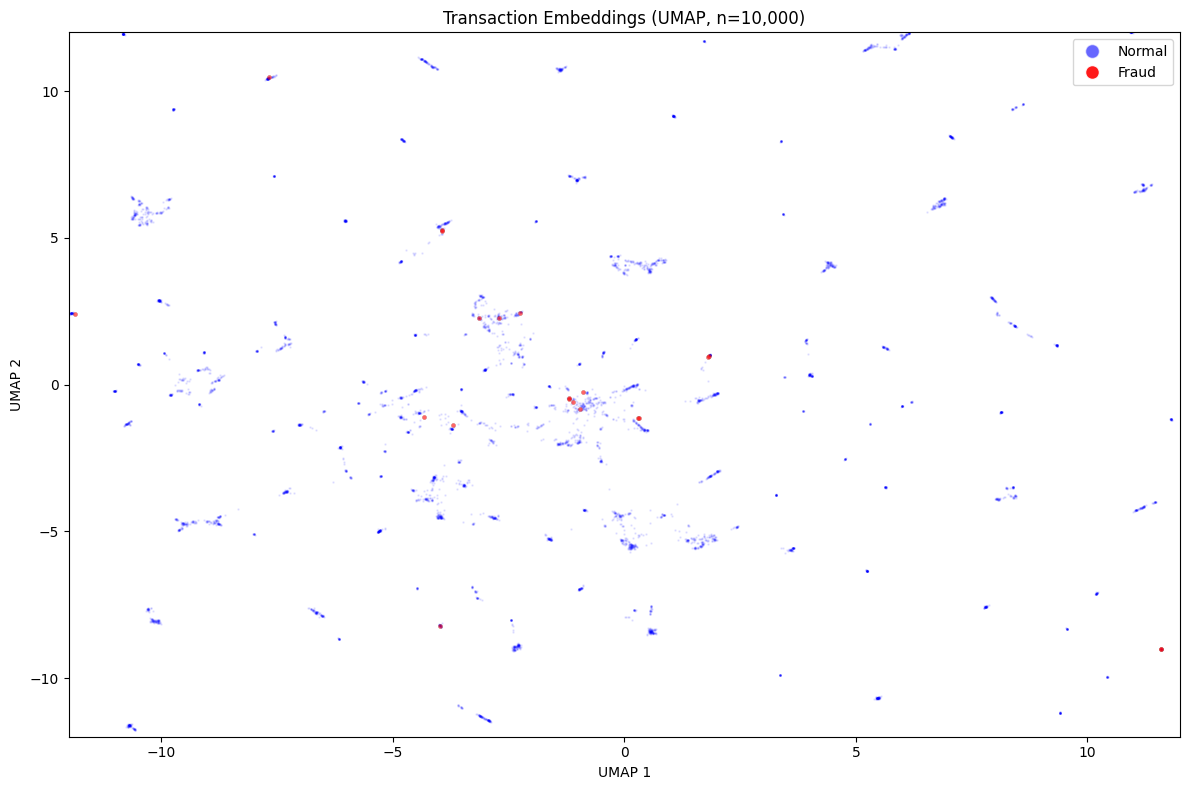

Saved → /content/data/embeddings/umap_visualization.png


In [103]:
import matplotlib
import plotly.graph_objects as go
import matplotlib.cm as _cm
from matplotlib.lines import Line2D
from IPython.display import IFrame, HTML, display as ipy_display

# ── Build viz_df (reused by the 3D interactive plot below) ────────────
viz_df = pd.DataFrame({
    "umap_1": umap_2d[:, 0],
    "umap_2": umap_2d[:, 1],
    "industry": subset_raw["industry"].fillna("Unknown").values,
    "mcc": subset_raw["MCC"].fillna(-1).astype(int).astype(str).values,
    "state": subset_raw["state"].fillna("XX").values,
    "chip_type": subset_raw["chip_type"].fillna("Unknown").values,
    "amount_bucket": subset_raw["amount_bucket"].fillna("Unknown").values,
    "zip3": subset_raw["zip3"].fillna("000").values,
    "fraud": ["Fraud" if l == 1 else "Normal" for l in subset_labels],
    "city": subset_raw["Merchant City"].fillna("Unknown").values,
})

def _tab20_hex(n):
    """Return n hex colors from matplotlib tab20."""
    cmap = matplotlib.colormaps["tab20"].resampled(max(n, 2))
    return [
        "#{:02x}{:02x}{:02x}".format(int(r*255), int(g*255), int(b*255))
        for r, g, b, _ in [cmap(i) for i in range(n)]
    ]

GRAY = "#d3d3d3"

# ── Static 2D scatter: Fraud vs Normal ────────────────────────────────
plt.figure(figsize=(12, 8))

if subset_labels is not None:
    mask_normal = (subset_labels == 0)
    mask_fraud = (subset_labels == 1)

    plt.scatter(
        umap_2d[mask_normal, 0], umap_2d[mask_normal, 1],
        c="blue", alpha=0.08, s=0.7, label="Normal",
    )
    plt.scatter(
        umap_2d[mask_fraud, 0], umap_2d[mask_fraud, 1],
        c="red", alpha=0.6, s=10, label="Fraud",
        edgecolor="k", linewidth=0.1,
    )
    plt.legend(handles=[
        Line2D([0], [0], marker="o", color="w", markerfacecolor="blue",
               markersize=10, alpha=0.6, label="Normal"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="red",
               markersize=10, alpha=0.9, label="Fraud"),
    ], loc="upper right")
else:
    plt.scatter(umap_2d[:, 0], umap_2d[:, 1], alpha=0.3, s=1)

plt.title(f"Transaction Embeddings (UMAP, n={len(subset_embeds):,})")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.xlim(-AXIS_RANGE, AXIS_RANGE)
plt.ylim(-AXIS_RANGE, AXIS_RANGE)
plt.tight_layout()
plt.savefig(EMBED_DIR / "umap_visualization.png", dpi=150)
plt.show()
print(f"Saved \u2192 {EMBED_DIR / 'umap_visualization.png'}")


# NP5 FINAL train xgboost

In [104]:
import sys
import json
import time
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import cudf
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.decomposition import PCA

import xgboost as xgb
import torch

In [105]:
print(f"cuDF version:    {cudf.__version__}")
print(f"XGBoost version: {xgb.__version__}")
print(f"GPU available:   {torch.cuda.is_available()}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU 0:           {props.name}, {props.total_memory / 1e9:.1f} GB")

DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
XGB_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

PROJECT_ROOT = Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

EMBED_DIR = PROJECT_ROOT / "data" / "embeddings"
TEMPORAL_DIR = PROJECT_ROOT / "data" / "TabFormer" / "temporal_split"
OUTPUTS_DIR = PROJECT_ROOT / "data" / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

assert EMBED_DIR.exists(), f"Embeddings directory not found: {EMBED_DIR}"
assert TEMPORAL_DIR.exists(), f"Temporal split directory not found: {TEMPORAL_DIR}"

print(f"\nEmbedding directory: {EMBED_DIR}")
print(f"Temporal split data: {TEMPORAL_DIR}")
print(f"Outputs directory:   {OUTPUTS_DIR}")


cuDF version:    26.06.00
XGBoost version: 3.4.1
GPU available:   True
GPU 0:           Tesla T4, 15.6 GB

Embedding directory: /content/data/embeddings
Temporal split data: /content/data/TabFormer/temporal_split
Outputs directory:   /content/data/outputs


In [106]:
with open(EMBED_DIR / "metadata.json") as f:
    metadata = json.load(f)

print("Embedding metadata:")
for key, value in metadata.items():
    if not isinstance(value, dict):
        print(f"  {key}: {value}")

Embedding metadata:
  backend: huggingface_decoder
  pooling: last_token
  model_path: /content/transaction-foundation-model/models/decoder-foundation-model
  n_samples: 89997
  embedding_dim: 512
  batch_size: 1024
  max_length: 128
  splits: ['train', 'val', 'test']
  n_train: 79997
  n_val: 5000
  n_test: 5000
  row_id_alignment: explicit_split_row_ids


In [107]:
# ------------------------------------------------------------------
# Load pre-computed train / val / test embeddings (foundation model, last-token)
# ------------------------------------------------------------------
print("\nLoading embeddings...")
t0 = time.time()
X_train_embed_raw = np.load(EMBED_DIR / "train_embeddings.npy")
y_train = np.load(EMBED_DIR / "train_labels.npy")
train_row_ids = np.load(EMBED_DIR / "train_row_ids.npy")

X_val_embed_raw = np.load(EMBED_DIR / "val_embeddings.npy")
y_val = np.load(EMBED_DIR / "val_labels.npy")
val_row_ids = np.load(EMBED_DIR / "val_row_ids.npy")

X_test_embed_raw = np.load(EMBED_DIR / "test_embeddings.npy")
y_test = np.load(EMBED_DIR / "test_labels.npy")
test_row_ids = np.load(EMBED_DIR / "test_row_ids.npy")

load_time = time.time() - t0
print(f"Loaded in {load_time:.1f}s")


Loading embeddings...
Loaded in 0.4s


In [108]:
n_train = len(X_train_embed_raw)
n_val = len(X_val_embed_raw)
n_test = len(X_test_embed_raw)

assert X_train_embed_raw.shape[0] == metadata['n_train'], "Train size mismatch"
assert X_val_embed_raw.shape[0] == metadata['n_val'], "Val size mismatch"
assert X_test_embed_raw.shape[0] == metadata['n_test'], "Test size mismatch"
assert X_train_embed_raw.shape[1] == metadata['embedding_dim'], "Embedding dim mismatch"

In [110]:
X_train_embed_raw.shape

(79997, 512)

In [112]:
embed_dim_orig = X_train_embed_raw.shape[1]

print(f"\nDataset sizes:")
print(f"  Training:   {len(X_train_embed_raw):,} samples")
print(f"  Validation: {len(X_val_embed_raw):,} samples")
print(f"  Test:       {len(X_test_embed_raw):,} samples")
print(f"  Embedding dimension: {embed_dim_orig}")

print(f"\nFraud distribution:")
print(f"  Training:   {y_train.sum():,.0f} fraud ({y_train.mean():.1%})")
print(f"  Validation: {y_val.sum():,.0f} fraud ({y_val.mean():.1%})")
print(f"  Test:       {y_test.sum():,.0f} fraud ({y_test.mean():.1%})")



Dataset sizes:
  Training:   79,997 samples
  Validation: 5,000 samples
  Test:       5,000 samples
  Embedding dimension: 512

Fraud distribution:
  Training:   83 fraud (0.1%)
  Validation: 17 fraud (0.3%)
  Test:       5 fraud (0.1%)


# 2. pca

In [113]:
PCA_DIM = 64

print(f"PCA: {embed_dim_orig}d -> {PCA_DIM}d")
t0 = time.time()
pca = PCA(n_components=PCA_DIM, random_state=42)
X_train_embed_pca = pca.fit_transform(X_train_embed_raw)
X_val_embed_pca = pca.transform(X_val_embed_raw)
X_test_embed_pca = pca.transform(X_test_embed_raw)
pca_time = time.time() - t0
print(f"  Explained variance: {pca.explained_variance_ratio_.sum():.2%}")
print(f"  PCA fit+transform time: {pca_time:.1f}s")
print(f"\nPCA complete: {PCA_DIM}d embeddings for both embeddings-only and combined models")

PCA: 512d -> 64d
  Explained variance: 92.43%
  PCA fit+transform time: 1.3s

PCA complete: 64d embeddings for both embeddings-only and combined models


# 3. Load and Align Raw Features

In [114]:
train_gdf = cudf.read_parquet(str(TEMPORAL_DIR / "train.parquet"))
val_gdf = cudf.read_parquet(str(TEMPORAL_DIR / "val_eval.parquet"))
test_gdf = cudf.read_parquet(str(TEMPORAL_DIR / "test_eval.parquet"))

In [121]:
print("\nFeature engineering with cuDF...")
t0 = time.time()
fraud_col = 'Is Fraud?'
for gdf in [train_gdf, val_gdf, test_gdf]:
    gdf['Hour'] = gdf['Time'].str.split(':', n=1, expand=True)[0].astype(int)

    gdf['Amount'] = gdf['Amount'].astype(str).str.replace('$', '', regex=False).str.replace(',', '').astype(float)
    gdf['_target'] = ((gdf[fraud_col] == 'Yes') | (gdf[fraud_col] == '1')).astype(int)
fe_time = time.time() - t0
print(f"cuDF feature engineering: {fe_time:.2f}s")



Feature engineering with cuDF...
cuDF feature engineering: 0.08s


In [122]:
train_gdf.head(5)

,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?,Hour,_target
0,0,0,2002,9,1,06:21,134.09,Swipe Transaction,3527213246127876953,La Verne,CA,91750.0,5300,None,No,6,0
1,0,0,2002,9,1,06:42,38.48,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,None,No,6,0
2,0,0,2002,9,2,06:22,120.34,Swipe Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,None,No,6,0
3,0,0,2002,9,2,17:45,128.95,Swipe Transaction,3414527459579106770,Monterey Park,CA,91754.0,5651,None,No,17,0
4,0,0,2002,9,3,06:23,104.71,Swipe Transaction,5817218446178736267,La Verne,CA,91750.0,5912,None,No,6,0


In [123]:
FEATURE_COLS = [
    'User', 'Card', 'Year', 'Month', 'Day', 'Hour', 'Amount',
    'Use Chip', 'Merchant Name', 'Merchant City', 'Merchant State',
    'Zip', 'MCC'
]

train_pdf = train_gdf.to_pandas()
val_pdf = val_gdf.to_pandas()
test_pdf = test_gdf.to_pandas()
del train_gdf, val_gdf, test_gdf

In [125]:
# Recreate balanced training indices (must match embedding extraction pipeline)
BALANCED_TOTAL = n_train
fraud_mask = (train_pdf[fraud_col] == "Yes") | (train_pdf[fraud_col] == "1")
fraud_idx = train_pdf.index[fraud_mask].tolist()
normal_idx = train_pdf.index[~fraud_mask].tolist()

np.random.seed(42)
n_fraud_target = min(len(fraud_idx), int(BALANCED_TOTAL * 0.1))
n_normal_target = min(len(normal_idx), BALANCED_TOTAL - n_fraud_target)
sampled_fraud = np.random.choice(fraud_idx, n_fraud_target, replace=False)
sampled_normal = np.random.choice(normal_idx, n_normal_target, replace=False)
balanced_idx = np.concatenate([sampled_fraud, sampled_normal])
np.random.shuffle(balanced_idx)

print(f"\nBalanced training sample: {len(balanced_idx):,} rows "
      f"({n_fraud_target:,} fraud + {n_normal_target:,} normal)")


Balanced training sample: 79,997 rows (83 fraud + 79,914 normal)


In [126]:
X_train_raw = train_pdf.loc[balanced_idx, FEATURE_COLS].reset_index(drop=True).iloc[train_row_ids].reset_index(drop=True)
X_val_raw = val_pdf.iloc[val_row_ids][FEATURE_COLS].reset_index(drop=True)
X_test_raw = test_pdf.iloc[test_row_ids][FEATURE_COLS].reset_index(drop=True)

print(f"\nRaw feature shapes (aligned with embedding splits):")
print(f"  Train: {X_train_raw.shape}")
print(f"  Val:   {X_val_raw.shape}")
print(f"  Test:  {X_test_raw.shape}")


Raw feature shapes (aligned with embedding splits):
  Train: (79997, 13)
  Val:   (5000, 13)
  Test:  (5000, 13)


In [127]:
print("Encoding categorical features...")
preprocessor = make_column_transformer(
    (OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
     make_column_selector(dtype_include=['object', 'category'])),
    remainder='passthrough'
)

t0 = time.time()
X_train_enc = preprocessor.fit_transform(X_train_raw)
X_val_enc = preprocessor.transform(X_val_raw)
X_test_enc = preprocessor.transform(X_test_raw)
enc_time = time.time() - t0
print(f"Encoding time: {enc_time:.2f}s")

print(f"\nEncoded features shape:")
print(f"  Train: {X_train_enc.shape}")
print(f"  Val:   {X_val_enc.shape}")
print(f"  Test:  {X_test_enc.shape}")

Encoding categorical features...
Encoding time: 0.11s

Encoded features shape:
  Train: (79997, 13)
  Val:   (5000, 13)
  Test:  (5000, 13)


In [128]:
XGB_PARAMS_RAW = {
    'n_estimators': 400,
    'max_depth': 8,
    'learning_rate': 0.0023,
    'colsample_bytree': 0.95,
    'min_child_weight': 12,
    'subsample': 0.673,
    'reg_alpha': 0.01,
    'reg_lambda': 0.001,
    'random_state': 42,
}

XGB_PARAMS_EMBED = {
    'n_estimators': 435,
    'max_depth': 12,
    'learning_rate': 0.03774,
    'colsample_bytree': 0.587,
    'min_child_weight': 2.61,
    'subsample': 0.569,
    'reg_alpha': 0.01364,
    'reg_lambda': 9.7e-05,
    'gamma': 1.7,
    'random_state': 42,
}

XGB_PARAMS_COMBINED = {
    'n_estimators': 512,
    'max_depth': 12,
    'learning_rate': 0.00305,
    'colsample_bytree': 0.768,
    'min_child_weight': 25.85,
    'subsample': 0.65,
    'reg_alpha': 0.01,
    'reg_lambda': 0.0001,
    'gamma': 4.8,
    'random_state': 42,
}


In [129]:
scale_pos_weight = 1.0
print(f"Class balance: scale_pos_weight = {scale_pos_weight} (no reweighting)")

Class balance: scale_pos_weight = 1.0 (no reweighting)


In [130]:
def train_xgb(X_train, y_train, X_val, y_val, X_test, y_test, params, name="Model"):
    """Train XGBoost with pre-optimized params and early stopping."""
    print(f"\nTraining {name}...")
    print(f"  Features: {X_train.shape[1]}d | Params: lr={params['learning_rate']}, "
          f"depth={params['max_depth']}, mcw={params['min_child_weight']}")
    t0 = time.time()
    clf = xgb.XGBClassifier(
        **params,
        scale_pos_weight=scale_pos_weight,
        tree_method='hist',
        device=XGB_DEVICE,
        early_stopping_rounds=20,
        eval_metric='auc',
    )
    clf.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    train_time = time.time() - t0

    val_preds = clf.predict_proba(X_val)[:, 1]
    val_auc = roc_auc_score(y_val, val_preds)
    val_ap = average_precision_score(y_val, val_preds)

    test_preds = clf.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, test_preds)
    test_ap = average_precision_score(y_test, test_preds)

    print(f"  Train time: {train_time:.1f}s (best_iteration={clf.best_iteration})")
    print(f"  Val  ROC-AUC: {val_auc:.4f} | AP: {val_ap:.4f}")
    print(f"  Test ROC-AUC: {test_auc:.4f} | AP: {test_ap:.4f}")

    return clf, {'val_auc': val_auc, 'val_ap': val_ap,
                 'test_auc': test_auc, 'test_ap': test_ap}


print("\n" + "=" * 60)
print("Training XGBoost Models (HPO-optimized params)")
print("=" * 60)


Training XGBoost Models (HPO-optimized params)


In [131]:
n_raw = X_train_enc.shape[1]

print(f"[1/3] BASELINE: Raw Tabular Features ({n_raw}d)")
clf_baseline, metrics_baseline = train_xgb(
    X_train_enc, y_train, X_val_enc, y_val, X_test_enc, y_test,
    params=XGB_PARAMS_RAW,
    name=f"Raw Features ({n_raw}d)"
)

print(f"\n[2/3] EMBEDDINGS: {PCA_DIM}d (PCA from {embed_dim_orig}d)")
clf_embed, metrics_embed = train_xgb(
    X_train_embed_pca, y_train, X_val_embed_pca, y_val, X_test_embed_pca, y_test,
    params=XGB_PARAMS_EMBED,
    name=f"Embeddings ({PCA_DIM}d PCA)"
)

print(f"\n[3/3] COMBINED: Raw {n_raw}d + PCA {PCA_DIM}d Embeddings")
X_train_combined = np.hstack([X_train_enc, X_train_embed_pca])
X_val_combined = np.hstack([X_val_enc, X_val_embed_pca])
X_test_combined = np.hstack([X_test_enc, X_test_embed_pca])
clf_combined, metrics_combined = train_xgb(
    X_train_combined, y_train, X_val_combined, y_val, X_test_combined, y_test,
    params=XGB_PARAMS_COMBINED,
    name=f"Combined ({X_train_combined.shape[1]}d)"
)

[1/3] BASELINE: Raw Tabular Features (13d)

Training Raw Features (13d)...
  Features: 13d | Params: lr=0.0023, depth=8, mcw=12
  Train time: 1.1s (best_iteration=0)
  Val  ROC-AUC: 0.8692 | AP: 0.0129
  Test ROC-AUC: 0.8630 | AP: 0.0036

[2/3] EMBEDDINGS: 64d (PCA from 512d)

Training Embeddings (64d PCA)...
  Features: 64d | Params: lr=0.03774, depth=12, mcw=2.61
  Train time: 2.7s (best_iteration=6)
  Val  ROC-AUC: 0.7584 | AP: 0.0078
  Test ROC-AUC: 0.7510 | AP: 0.0023

[3/3] COMBINED: Raw 13d + PCA 64d Embeddings

Training Combined (77d)...
  Features: 77d | Params: lr=0.00305, depth=12, mcw=25.85
  Train time: 4.4s (best_iteration=0)
  Val  ROC-AUC: 0.5743 | AP: 0.0040
  Test ROC-AUC: 0.5277 | AP: 0.0011
